In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [2]:
df = pd.read_csv('/kaggle/input/tutorial-competition-for-beginners/test.csv')
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1,2,113781,151.5500,C22 C26,S
1,893,1,"Astor, Col. John Jacob",male,47.0,1,0,PC 17757,227.5250,C62 C64,C
2,894,1,"Beattie, Mr. Thomson",male,36.0,0,0,13050,75.2417,C6,C
3,895,1,"Bird, Miss. Ellen",female,29.0,0,0,PC 17483,221.7792,C97,S
4,896,1,"Birnbaum, Mr. Jakob",male,25.0,0,0,13905,26.0000,NaN,C


In [21]:
num_rows = df.shape[0]
print(f"Number of rows: {num_rows}")

num_columns = df.shape[1]
print(f"Number of columns:{num_columns}")

data_types = df.dtypes
print("\nData types of variables:")
print(data_types)

continuous_vars = data_types[data_types.apply(lambda x: pd.api.types.is_numeric_dtype(x))]
categorical_vars = data_types[data_types.apply(lambda x: pd.api.types.is_categorical_dtype(x) or pd.api.types.is_object_dtype(x))]

print("\nNumber of continuous variables:",len(continuous_vars))
print("Continuous variables:",continuous_vars.index.tolist())

print("\nNumber of categorical variables:",len(categorical_vars))
print("Categorical variables:",categorical_vars.index.tolist())

Number of rows: 416
Number of columns:11

Data types of variables:
PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Number of continuous variables: 6
Continuous variables: ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Number of categorical variables: 5
Categorical variables: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


/tmp/ipykernel_30/1529625583.py:12: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categorical_vars = data_types[data_types.apply(lambda x: pd.api.types.is_categorical_dtype(x) or pd.api.types.is_object_dtype(x))]


In [22]:
five_point_summary = df.describe(percentiles=[0.25,0.5,0.75])
print("Five point summary:")
print(five_point_summary.loc[['min','25%','50%','75%','max']])

Five point summary:
     PassengerId  Pclass      Age  SibSp  Parch      Fare
min       892.00     1.0   0.1667    0.0    0.0    0.0000
25%       995.75     1.0  21.0000    0.0    0.0    7.8958
50%      1099.50     3.0  27.0000    0.0    0.0   14.4542
75%      1203.25     3.0  39.0000    1.0    0.0   31.5000
max      1307.00     3.0  76.0000    8.0    9.0  512.3292


In [23]:
statistical_summary = df.describe()
print("Statistical summary for numerical variables:")
print(statistical_summary)

Statistical summary for numerical variables:
       PassengerId      Pclass         Age       SibSp       Parch        Fare
count   416.000000  416.000000  330.000000  416.000000  416.000000  415.000000
mean   1099.500000    2.262019   30.260606    0.449519    0.394231   35.761637
std     120.233107    0.842315   14.222325    0.898379    0.983412   56.008739
min     892.000000    1.000000    0.166700    0.000000    0.000000    0.000000
25%     995.750000    1.000000   21.000000    0.000000    0.000000    7.895800
50%    1099.500000    3.000000   27.000000    0.000000    0.000000   14.454200
75%    1203.250000    3.000000   39.000000    1.000000    0.000000   31.500000
max    1307.000000    3.000000   76.000000    8.000000    9.000000  512.329200


In [33]:
print("Original data types:")
print(df.dtypes)

df['Age'] = df['Age'].astype('object')
df['Parch'] = df['Parch'].astype('object')

print("\nNew DataTypes:")
print(df.dtypes)

print("\nData preview:")
print(df[['Age','Parch']].head())

Original data types:
PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

New DataTypes:
PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age             object
SibSp            int64
Parch           object
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Data preview:
    Age Parch
0  30.0     2
1  47.0     0
2  36.0     0
3  29.0     0
4  25.0     0


In [29]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1,2,113781,151.5500,C22 C26,S
1,893,1,"Astor, Col. John Jacob",male,47.0,1,0,PC 17757,227.5250,C62 C64,C
2,894,1,"Beattie, Mr. Thomson",male,36.0,0,0,13050,75.2417,C6,C
3,895,1,"Bird, Miss. Ellen",female,29.0,0,0,PC 17483,221.7792,C97,S
4,896,1,"Birnbaum, Mr. Jakob",male,25.0,0,0,13905,26.0000,NaN,C


In [32]:
relevant_features = ['Age','SibSp','Fare']

def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    return (data < lower_bound) | (data> upper_bound)

for feature in relevant_features:
    if feature in df.columns:
        outliers = detect_outliers_iqr(df[feature])
        num_outliers = outliers.sum()
        print(F"Number of outliers in '{feature}': {num_outliers}")
        if num_outliers >0:
            outlier_values = df[feature][outliers]
            print(F"Outlier values for '{feature}':")
            print(outlier_values.tolist())
  

Number of outliers in 'Age': 2
Outlier values for 'Age':
[76.0, 67.0]
Number of outliers in 'SibSp': 11
Outlier values for 'SibSp':
[3, 4, 4, 4, 5, 3, 3, 4, 8, 8, 3]
Number of outliers in 'Fare': 55
Outlier values for 'Fare':
[151.55, 227.525, 75.2417, 221.7792, 164.8667, 262.375, 76.2917, 512.3292, 78.85, 262.375, 136.7792, 136.7792, 83.1583, 83.1583, 71.2833, 151.55, 81.8583, 81.8583, 247.5208, 106.425, 83.1583, 263.0, 263.0, 79.2, 211.5, 93.5, 211.5, 211.3375, 75.2417, 90.0, 108.9, 93.5, 79.2, 262.375, 262.375, 262.375, 82.2667, 82.2667, 134.5, 134.5, 146.5208, 221.7792, 221.7792, 75.25, 135.6333, 164.8667, 211.5, 211.5, 134.5, 73.5, 73.5, 69.55, 69.55, 69.55, 69.55]


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  416 non-null    int64  
 1   Pclass       416 non-null    int64  
 2   Name         416 non-null    object 
 3   Sex          416 non-null    object 
 4   Age          330 non-null    float64
 5   SibSp        416 non-null    int64  
 6   Parch        416 non-null    int64  
 7   Ticket       416 non-null    object 
 8   Fare         415 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     416 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 35.9+ KB


In [6]:
df.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,416.0,1099.500000,120.233107,892.0000,995.7500,1099.5000,1203.25,1307.0000
Pclass,416.0,2.262019,0.842315,1.0000,1.0000,3.0000,3.00,3.0000
Age,330.0,30.260606,14.222325,0.1667,21.0000,27.0000,39.00,76.0000
SibSp,416.0,0.449519,0.898379,0.0000,0.0000,0.0000,1.00,8.0000
Parch,416.0,0.394231,0.983412,0.0000,0.0000,0.0000,0.00,9.0000
Fare,415.0,35.761637,56.008739,0.0000,7.8958,14.4542,31.50,512.3292


In [13]:
df.isnull().sum()/len(df*50)

PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.206731
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.002404
Cabin          0.781250
Embarked       0.000000
dtype: float64

In [15]:
df.shape

(416, 11)

<Axes: >

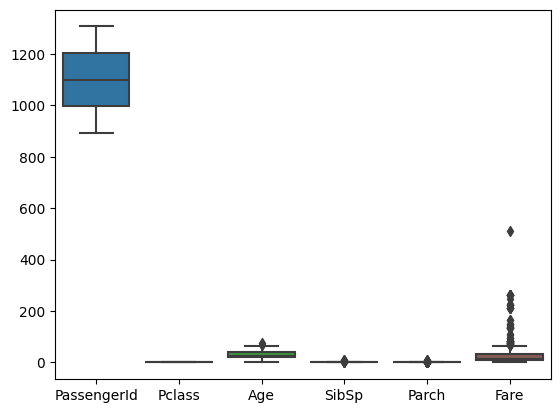

In [20]:
sns.boxplot(df)

<Axes: >

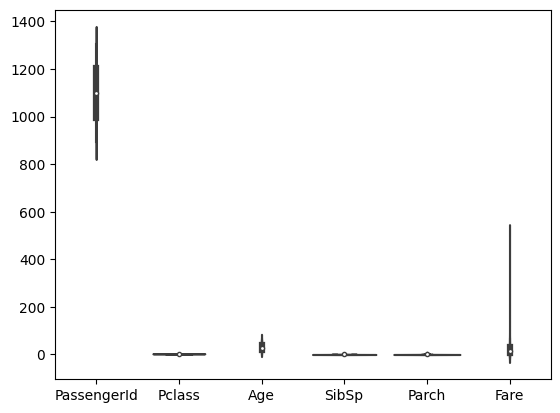

In [21]:
sns.violinplot(df)

<Axes: >

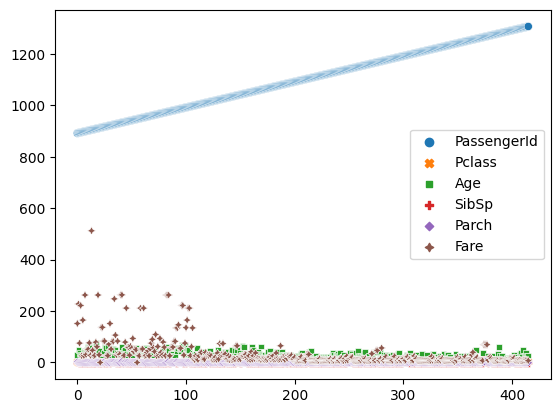

In [22]:
sns.scatterplot(df)

<Axes: >

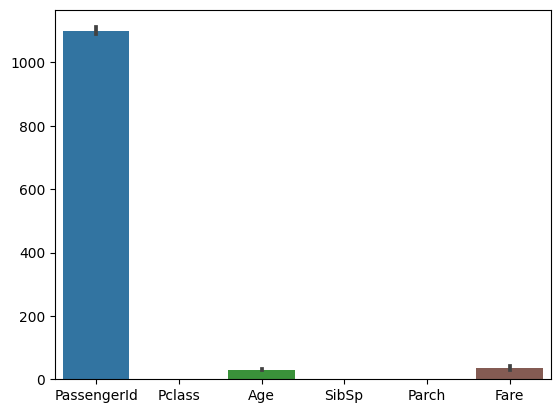

In [23]:
sns.barplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

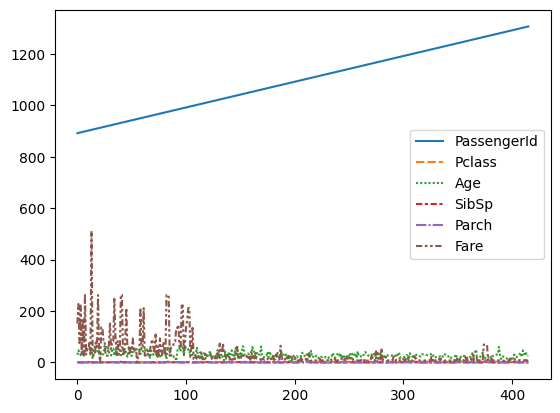

In [24]:
sns.lineplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

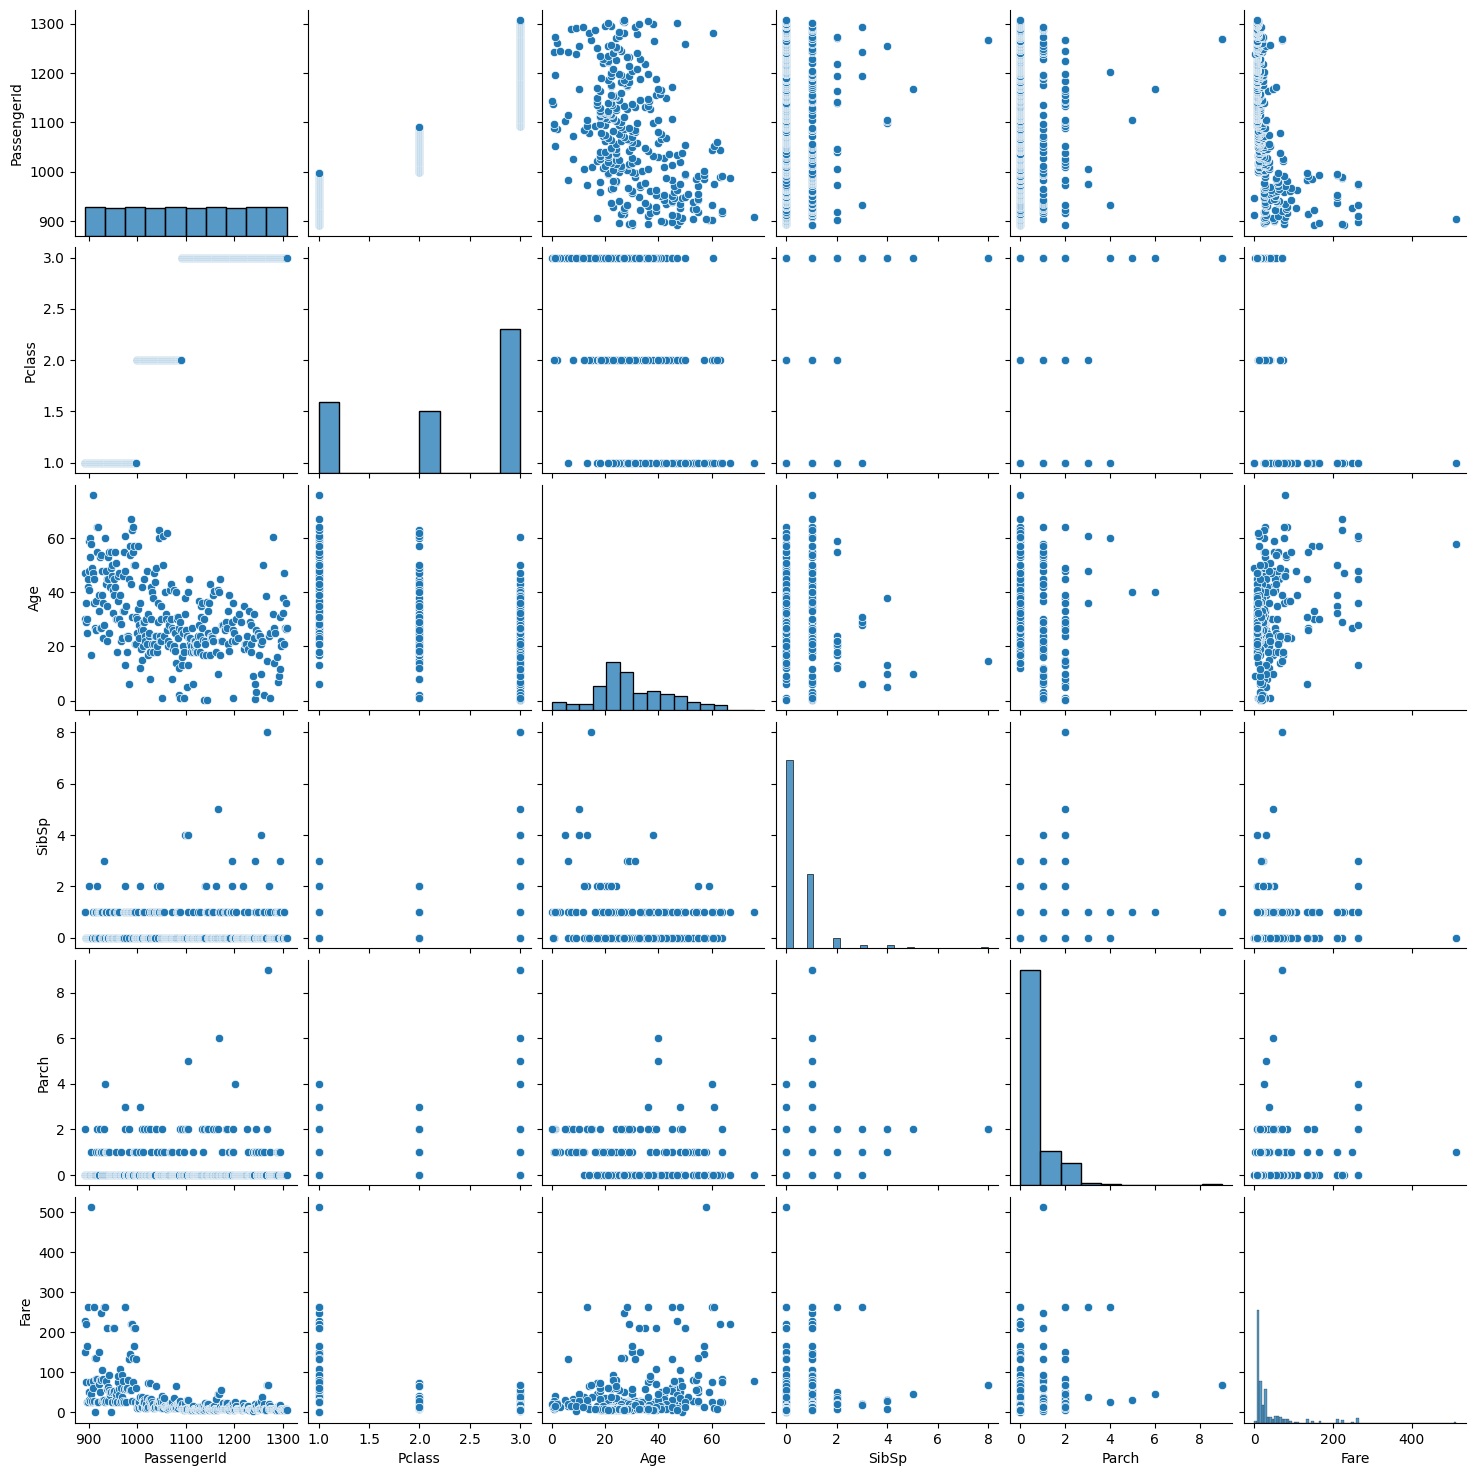

In [25]:
sns.pairplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

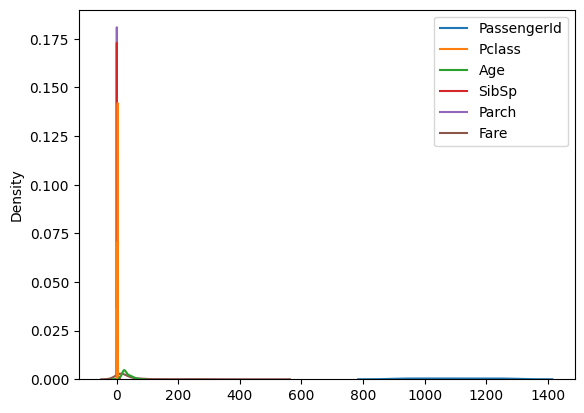

In [26]:
sns.kdeplot(df)

In [31]:
df.kurt

<bound method DataFrame.kurt of      PassengerId  Pclass                                  Name     Sex   Age  \
0            892       1  Allison, Mr. Hudson Joshua Creighton    male  30.0   
1            893       1                Astor, Col. John Jacob    male  47.0   
2            894       1                  Beattie, Mr. Thomson    male  36.0   
3            895       1                     Bird, Miss. Ellen  female  29.0   
4            896       1                   Birnbaum, Mr. Jakob    male  25.0   
..           ...     ...                                   ...     ...   ...   
411         1303       3      Willer, Mr. Aaron ("Abi Weller")    male   NaN   
412         1304       3                      Wirz, Mr. Albert    male  27.0   
413         1305       3             Wittevrongel, Mr. Camille    male  36.0   
414         1306       3             Zakarian, Mr. Mapriededer    male  26.5   
415         1307       3                   Zakarian, Mr. Ortin    male  27.0   

     Si

In [30]:
df.skew

<bound method DataFrame.skew of      PassengerId  Pclass                                  Name     Sex   Age  \
0            892       1  Allison, Mr. Hudson Joshua Creighton    male  30.0   
1            893       1                Astor, Col. John Jacob    male  47.0   
2            894       1                  Beattie, Mr. Thomson    male  36.0   
3            895       1                     Bird, Miss. Ellen  female  29.0   
4            896       1                   Birnbaum, Mr. Jakob    male  25.0   
..           ...     ...                                   ...     ...   ...   
411         1303       3      Willer, Mr. Aaron ("Abi Weller")    male   NaN   
412         1304       3                      Wirz, Mr. Albert    male  27.0   
413         1305       3             Wittevrongel, Mr. Camille    male  36.0   
414         1306       3             Zakarian, Mr. Mapriededer    male  26.5   
415         1307       3                   Zakarian, Mr. Ortin    male  27.0   

     Si

In [32]:
cat_cols = df.select_dtypes(include='object')

In [34]:
for i in cat_cols:
    print(i)
    (df[i].value_counts())
    print('\n')
    print(''*50)

Name



Sex



Ticket



Cabin



Embarked





In [35]:
num_cols = df.select_dtypes(include='number')

In [38]:
for i in num_cols:
    print(i)
    (df[i].value_counts())
    print('\n')
    print(''*50)

PassengerId



Pclass



Age



SibSp



Parch



Fare





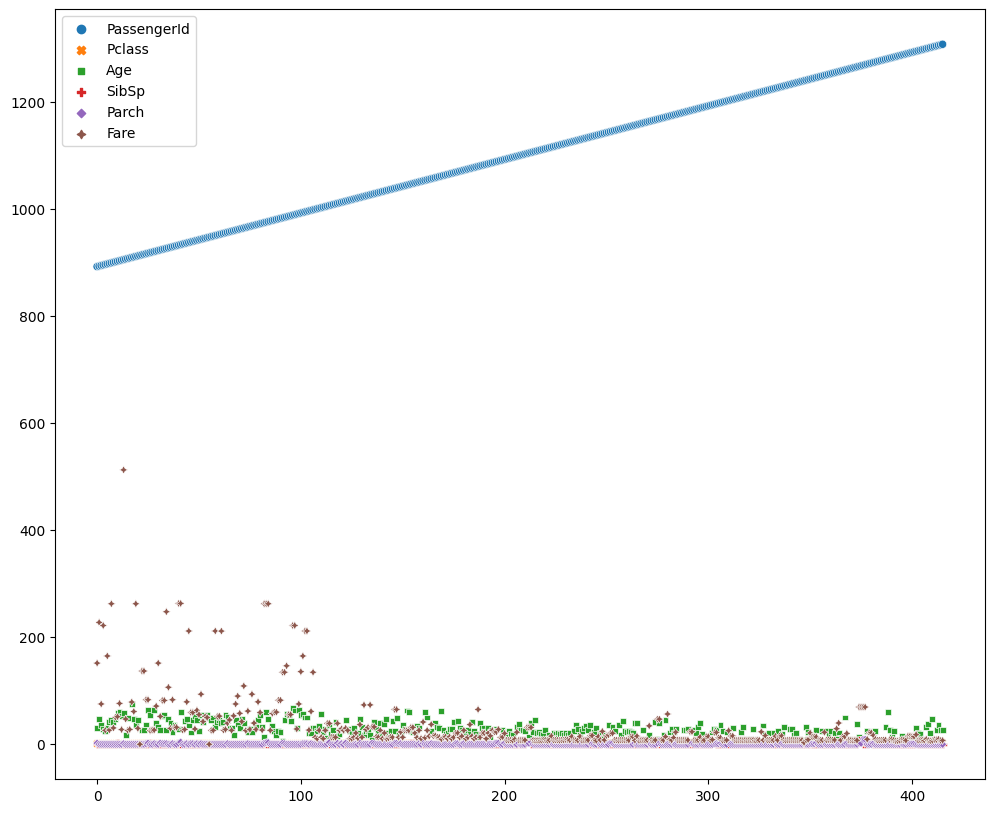

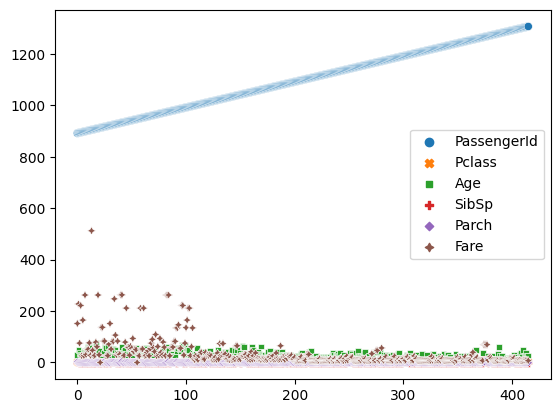

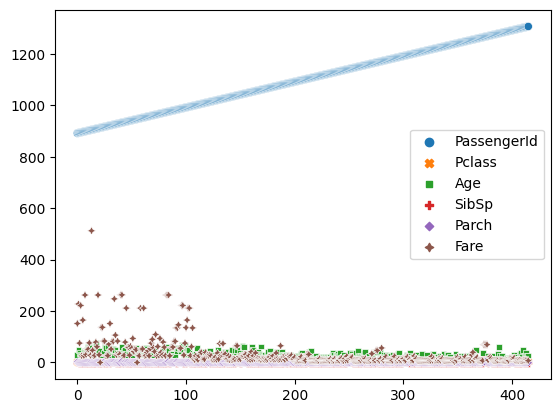

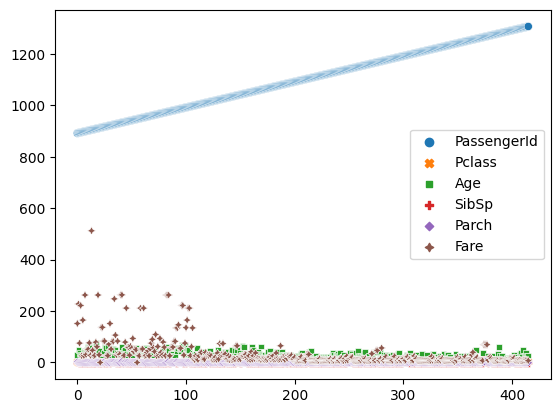

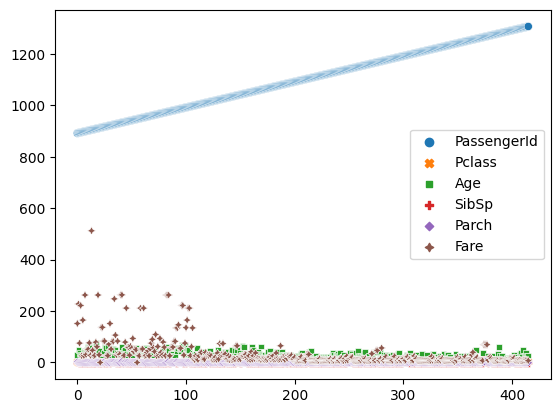

In [40]:
x = 1
plt.figure(figsize=(12,10))
cat_cols = df.select_dtypes(include='object')
for i in cat_cols:
    sns.scatterplot(data=df)
    print('\n')
    plt.show()

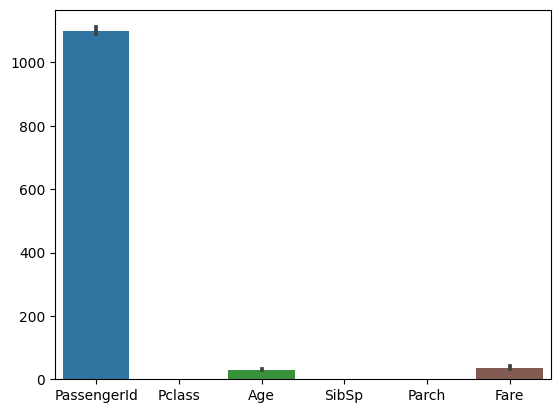

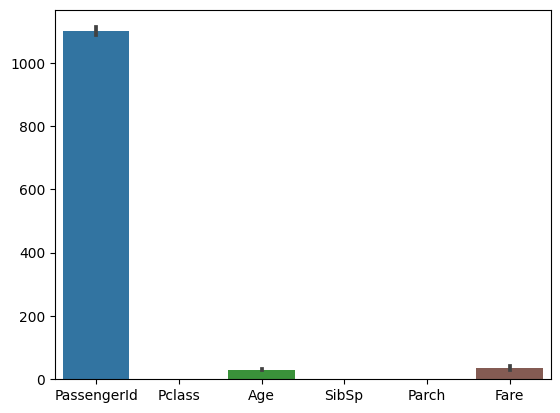

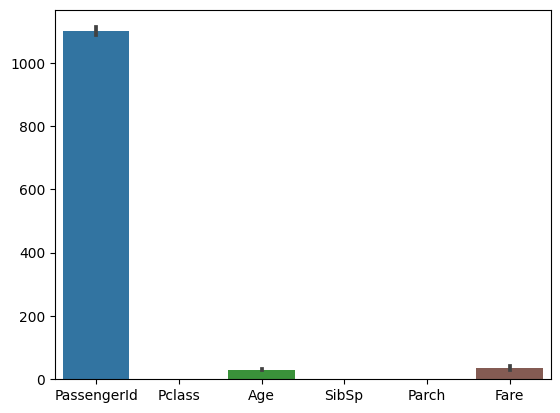

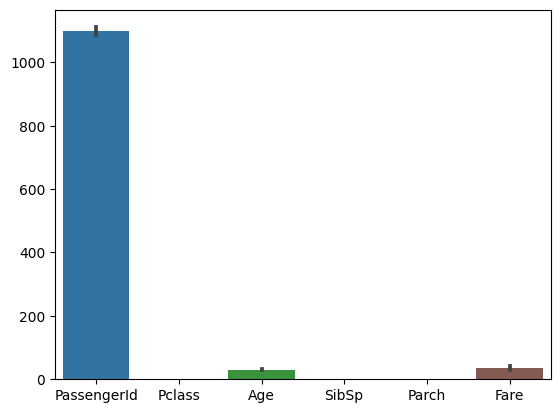

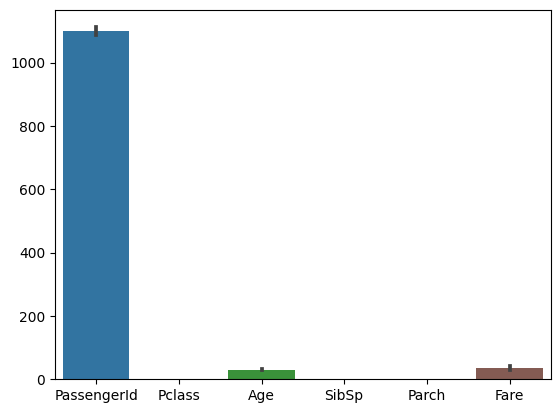

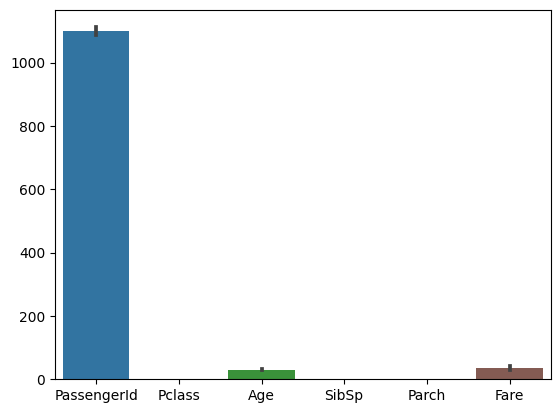

In [41]:
x = 1
num_cols = df.select_dtypes(include='number')
for i in num_cols:
    sns.barplot(data=df)
    print('\n')
    plt.show()

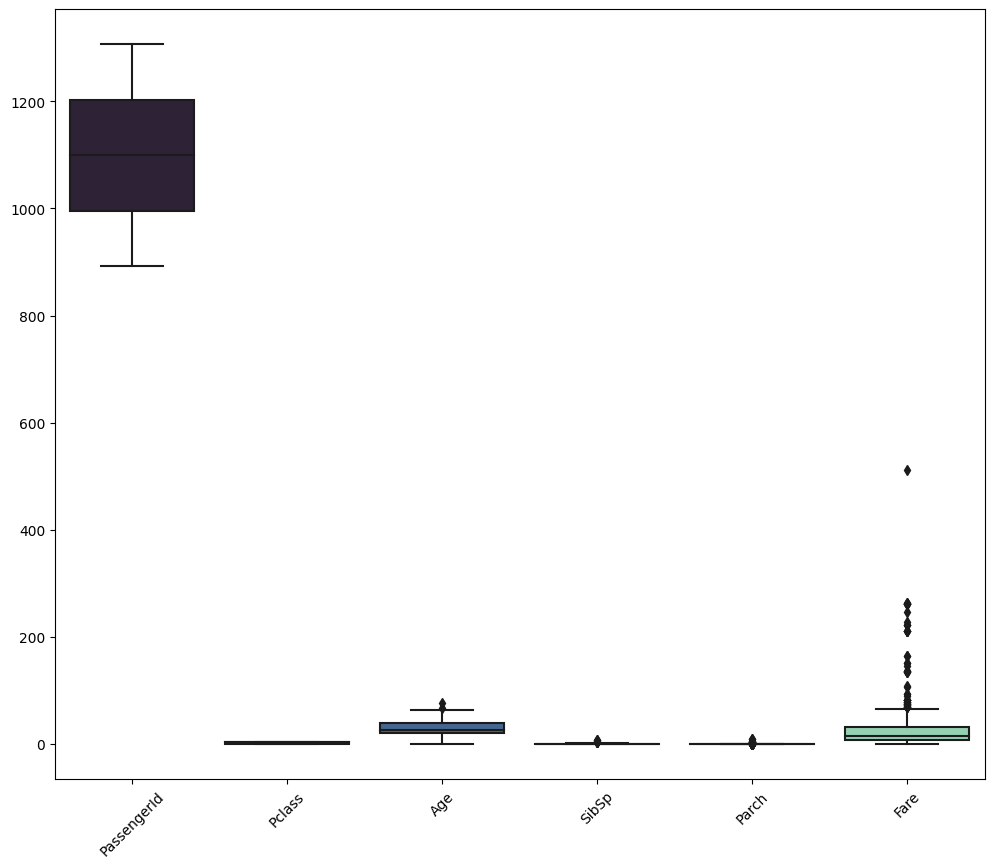

In [42]:
plt.figure(figsize=(12,10))
sns.boxplot(data=df,palette='mako');
plt.xticks(rotation=45);
plt.show()

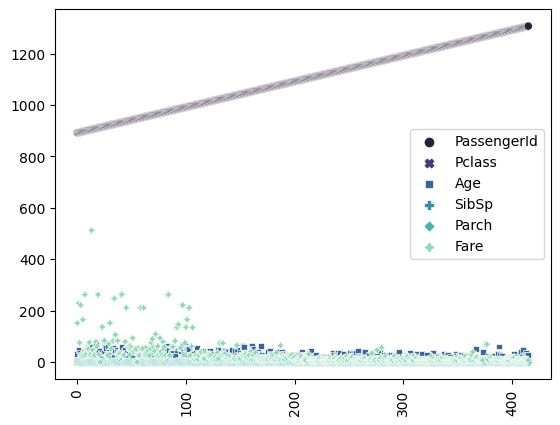

In [43]:
sns.scatterplot(data=df,palette='mako');
plt.xticks(rotation=90)
plt.show()

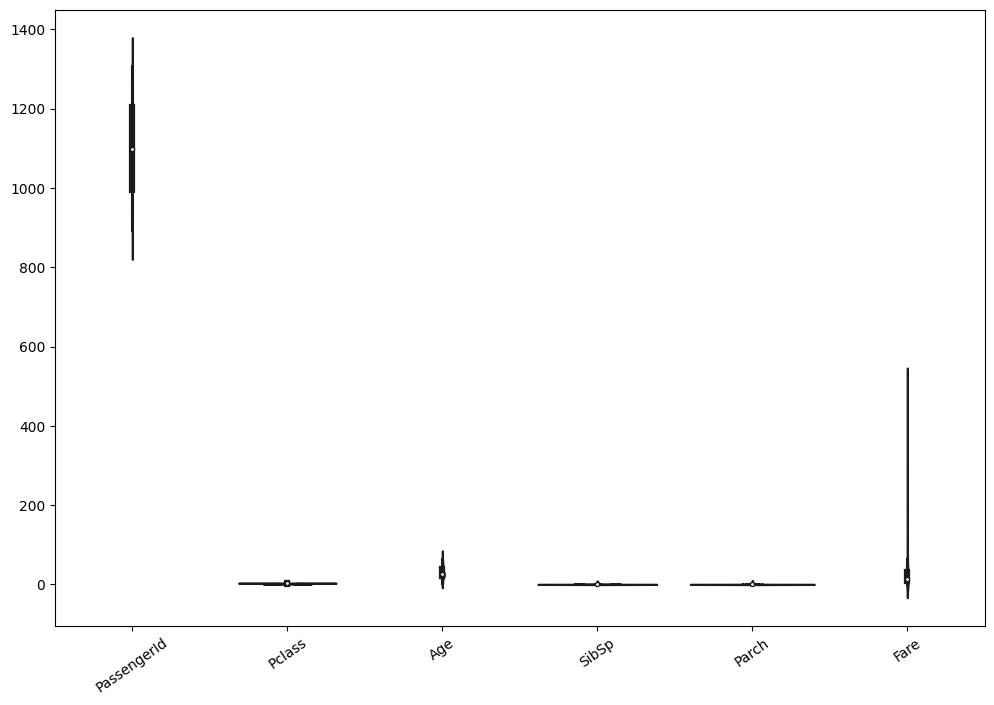

In [44]:
plt.figure(figsize=(12,8))
sns.violinplot(data=df,palette='mako');
plt.xticks(rotation=35);
plt.show()

In [45]:
import plotly.express as px
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
import warnings
warnings.filterwarnings('ignore')

In [46]:
df.head(
    
)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1,2,113781,151.5500,C22 C26,S
1,893,1,"Astor, Col. John Jacob",male,47.0,1,0,PC 17757,227.5250,C62 C64,C
2,894,1,"Beattie, Mr. Thomson",male,36.0,0,0,13050,75.2417,C6,C
3,895,1,"Bird, Miss. Ellen",female,29.0,0,0,PC 17483,221.7792,C97,S
4,896,1,"Birnbaum, Mr. Jakob",male,25.0,0,0,13905,26.0000,NaN,C


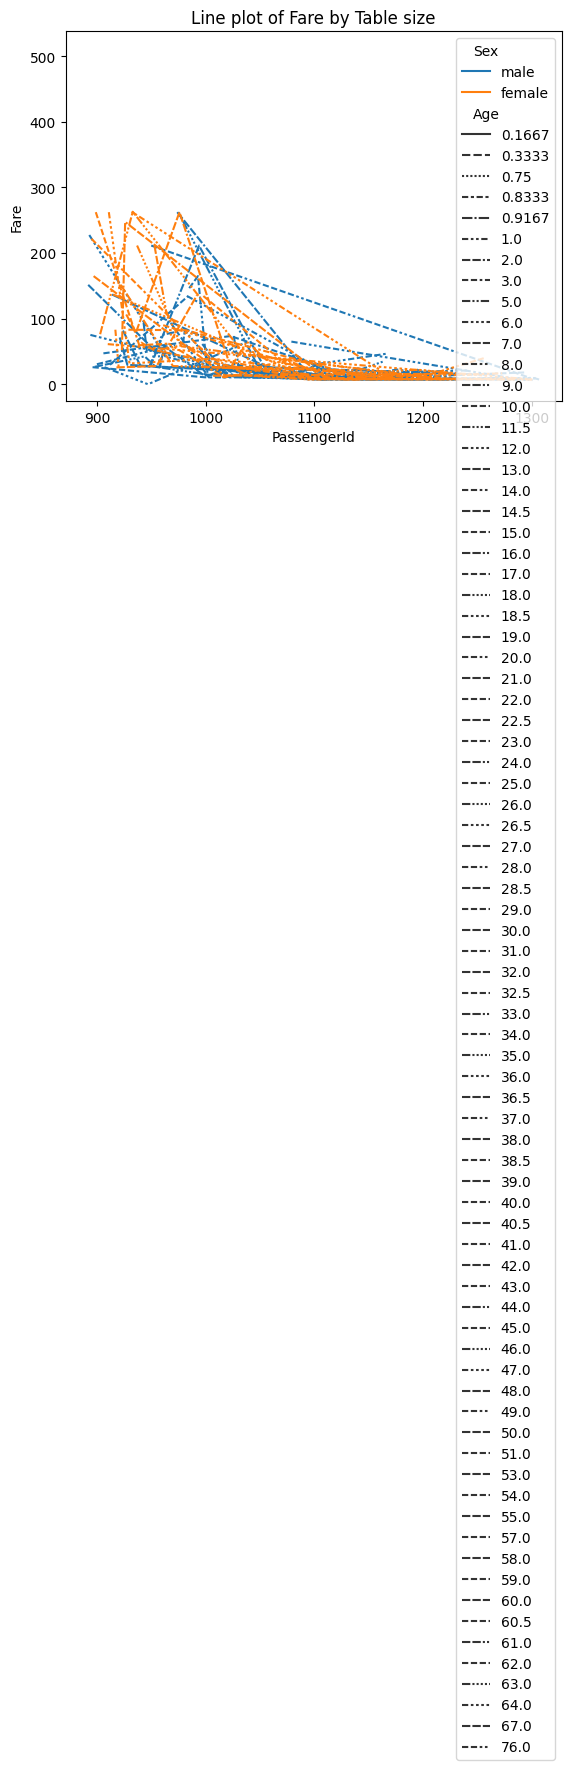

In [47]:
sns.lineplot(x='PassengerId', y='Fare', data=df, hue='Sex', style='Age')
plt.title("Line plot of Fare by Table size")
plt.show()

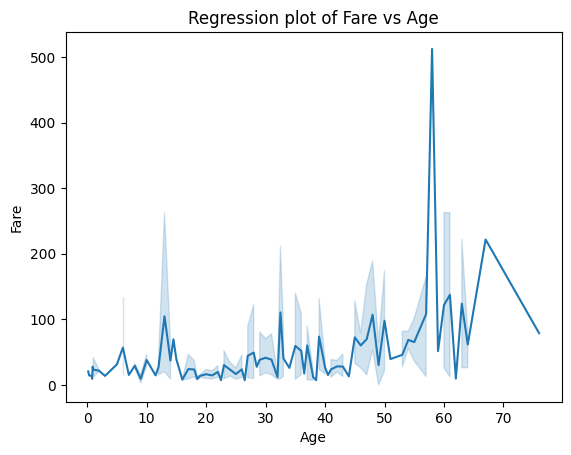

In [54]:
sns.lineplot(x='Age', y='Fare', data=df,)
plt.title("Regression plot of Fare vs Age")
plt.show()

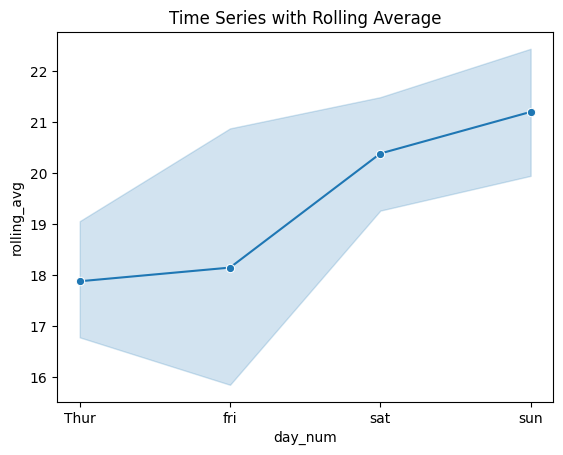

In [55]:
df_tips = sns.load_dataset("tips")
df_tips['day_num'] = df_tips['day'].astype('category').cat.codes

df_tips['rolling_avg'] = df_tips['total_bill']. rolling(window=3).mean()

sns.lineplot(x='day_num', y='rolling_avg', data=df_tips,marker='o')
plt.xticks(ticks=[0,1,2,3],labels=["Thur",'fri','sat','sun'])
plt.title("Time Series with Rolling Average")
plt.show()

In [56]:
statistical_summary = df.describe()
print("Statistical summary for numerical variables:")
print(statistical_summary)

Statistical summary for numerical variables:
       PassengerId      Pclass         Age       SibSp       Parch        Fare
count   416.000000  416.000000  330.000000  416.000000  416.000000  415.000000
mean   1099.500000    2.262019   30.260606    0.449519    0.394231   35.761637
std     120.233107    0.842315   14.222325    0.898379    0.983412   56.008739
min     892.000000    1.000000    0.166700    0.000000    0.000000    0.000000
25%     995.750000    1.000000   21.000000    0.000000    0.000000    7.895800
50%    1099.500000    3.000000   27.000000    0.000000    0.000000   14.454200
75%    1203.250000    3.000000   39.000000    1.000000    0.000000   31.500000
max    1307.000000    3.000000   76.000000    8.000000    9.000000  512.329200


In [57]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering, DBSCAN

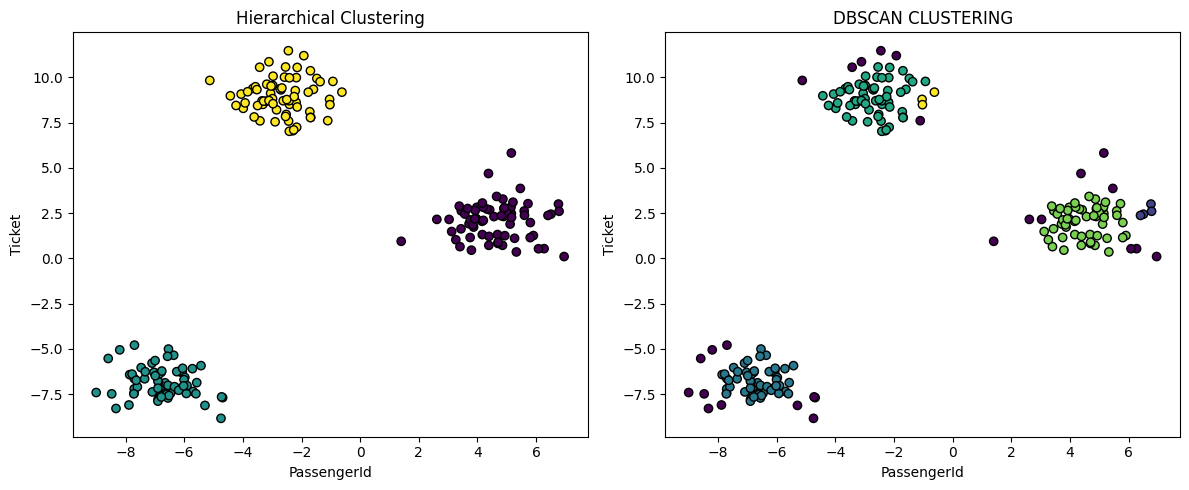

In [59]:
x, _ = make_blobs(n_samples=200, centers=3, random_state=42)

agg_clustering = AgglomerativeClustering(n_clusters=3)
agg_clusters = agg_clustering.fit_predict(x)

dbscan = DBSCAN(eps=0.6, min_samples=3)
dbscan_clusters = dbscan.fit_predict(x)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(x[:,0],x[:,1], c=agg_clusters, cmap='viridis', edgecolors='k')
plt.title('Hierarchical Clustering')
plt.xlabel('PassengerId')
plt.ylabel('Ticket')

plt.subplot(1,2,2)
plt.scatter(x[:,0],x[:,1],c=dbscan_clusters, cmap='viridis',edgecolors='k')
plt.title('DBSCAN CLUSTERING')
plt.xlabel('PassengerId')
plt.ylabel('Ticket')
plt.tight_layout()

plt.show()

In [58]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1,2,113781,151.5500,C22 C26,S
1,893,1,"Astor, Col. John Jacob",male,47.0,1,0,PC 17757,227.5250,C62 C64,C
2,894,1,"Beattie, Mr. Thomson",male,36.0,0,0,13050,75.2417,C6,C
3,895,1,"Bird, Miss. Ellen",female,29.0,0,0,PC 17483,221.7792,C97,S
4,896,1,"Birnbaum, Mr. Jakob",male,25.0,0,0,13905,26.0000,NaN,C


In [60]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs


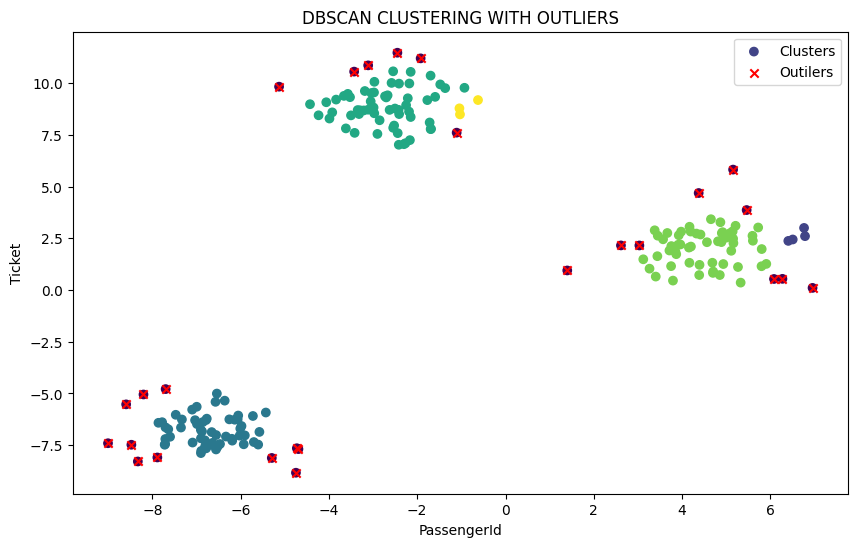

In [64]:
x, _ = make_blobs(n_samples=200, centers=3, random_state=42)

dbscan = DBSCAN(eps=0.6, min_samples=3)
clusters = dbscan.fit_predict(x)

outliers = x[clusters == -1]

df = pd.DataFrame(x, columns=['PassengerId','Ticket'])
df['Cluster'] = clusters

plt.figure(figsize=(10,6))
plt.scatter(x[:,0], x[:,1], c=clusters, cmap='viridis', label='Clusters')
plt.scatter(outliers[:,0], outliers[:,1], c='red', marker='x',label='Outilers')
plt.title('DBSCAN CLUSTERING WITH OUTLIERS')
plt.xlabel('PassengerId')
plt.ylabel('Ticket')
plt.legend()
plt.show()

In [67]:
x = df[['PassengerId']]

In [68]:
y=df[['Ticket']]

In [69]:
from sklearn.model_selection import train_test_split

In [71]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)


In [72]:
from sklearn.linear_model import LinearRegression

In [73]:
lr = LinearRegression()

In [74]:
lr.fit(x_train,y_train)

LinearRegression()

In [75]:
y_pred=lr.predict(x_test)


In [76]:
y_test.head(),y_pred[0:5]

(       Ticket
 47  -7.265423
 110  2.754993
 86  -6.833129
 27  -6.291792
 152  3.869963,
 array([[-1.17169121],
        [ 4.93779641],
        [-1.20537461],
        [-1.28730453],
        [ 5.23111297]]))

In [77]:
from sklearn.metrics import mean_squared_error

In [78]:
mean_squared_error(y_test,y_pred)

34.51624427730979

In [84]:
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [94]:
# Load the Iris dataset (preloaded dataset in scikit-learn)
X = df.Ticket
y = df.PassengerId  # Target labels

# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
